In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ISAT

In [ ]:
ticker = "ISAT.JK"
start_date = "2021-12-31"
end_date = "2023-12-18"

data = yf.download(ticker, start=start_date, end=end_date)

print(data)

[*********************100%%**********************]  1 of 1 completed
              Open    High     Low   Close    Adj Close    Volume
Date                                                             
2022-01-03  6200.0  6450.0  6175.0  6425.0  6003.483398   8106600
2022-01-04  6425.0  6475.0  6150.0  6250.0  5839.964355   6697700
2022-01-05  6300.0  6350.0  6050.0  6150.0  5746.525391   5903500
2022-01-06  6150.0  6325.0  6125.0  6300.0  5886.684082   3908300
2022-01-07  6300.0  6350.0  6225.0  6300.0  5886.684082   5461600
...            ...     ...     ...     ...          ...       ...
2023-12-11  9350.0  9425.0  9225.0  9350.0  9350.000000   1903100
2023-12-12  9350.0  9800.0  9350.0  9675.0  9675.000000   3486400
2023-12-13  9675.0  9775.0  9425.0  9475.0  9475.000000   3098100
2023-12-14  9500.0  9725.0  9350.0  9550.0  9550.000000   1853400
2023-12-15  9575.0  9675.0  9500.0  9500.0  9500.000000  20213000

[477 rows x 6 columns]


# 50,50,50,30




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(30, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 30, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_2 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_3 (LSTM)               (None, 30)                9

In [ ]:
# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 10s 43ms/step - loss: 0.0626
Epoch 2/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0208
Epoch 3/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0188
Epoch 4/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0201
Epoch 5/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0177
Epoch 6/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0182
Epoch 7/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0159
Epoch 8/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0166
Epoch 9/200
22/22 [==============================] - 1s 65ms/step - loss: 0.0162
Epoch 10/200
22/22 [==============================] - 2s 70ms/step - loss: 0.0159
Epoch 11/200
22/22 [==============================] - 1s 64ms/step - loss: 0.0155
Epoch 12/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0142
Epoch 13/200
22/22 [====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 19ms/step
Root mean squared error: 93.32487282945849


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 18ms/step
Root mean squared error: 191.58155307615232


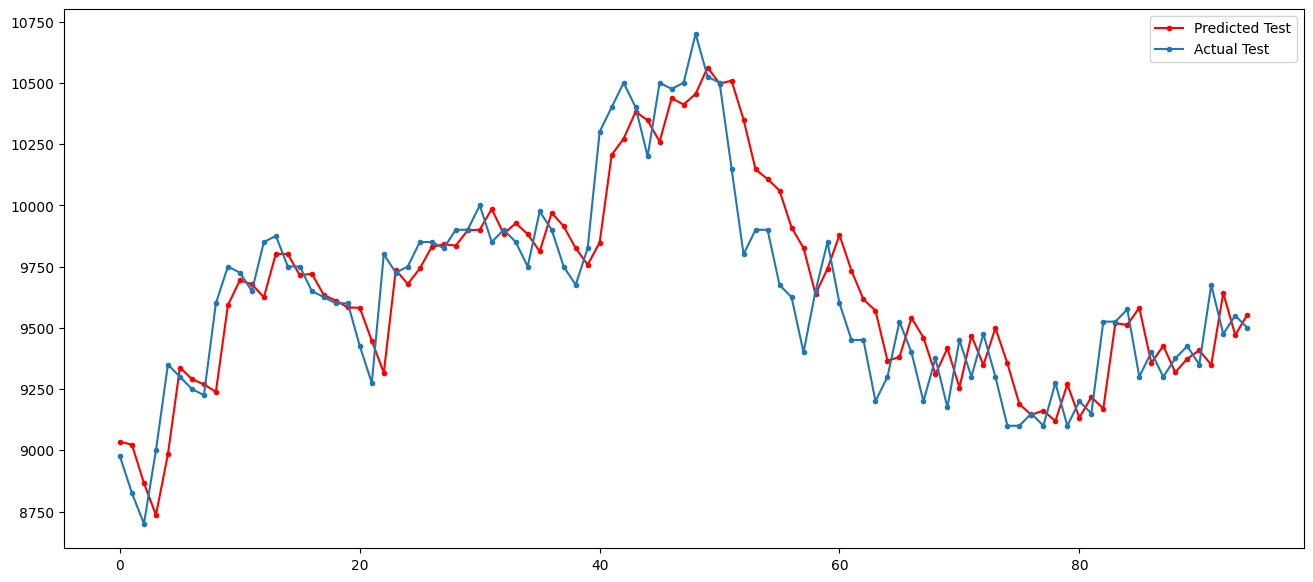

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 43ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     9498.667969
1   2023-12-19     9499.953125
2   2023-12-20     9496.230469
3   2023-12-21     9492.643555
4   2023-12-22     9489.674805
5   2023-12-25     9487.701172
6   2023-12-26     9486.665039
7   2023-12-27     9486.835938
8   2023-12-28     9488.114258
9   2023-12-29     9490.652344
10  2024-01-01     9494.510742
11  2024-01-02     9499.510742
12  2024-01-03     9505.460938
13  2024-01-04     9512.257812
14  2024-01-05     9519.623047
15  2024-01-08     9527.574219
16  2024-01-09     9535.886719
17  2024-01-10     9544.485352
18  2024-01-11     9553.010742
19  2024-01-12     9561.477539
20  2024-01-15     9569.865234
21  2024-01-16     9578.363281


In [ ]:
predicted_df['Prediksi_Harga']=predicted_df['Prediksi_Harga'].round(decimals=0)

In [ ]:
predicted_df.to_csv('ISAT.csv')

In [ ]:
test_data = close_prices[training_data_len:]
test_data

Date
2023-08-03    8975.0
2023-08-04    8825.0
2023-08-07    8700.0
2023-08-08    9000.0
2023-08-09    9350.0
               ...  
2023-12-11    9350.0
2023-12-12    9675.0
2023-12-13    9475.0
2023-12-14    9550.0
2023-12-15    9500.0
Name: Close, Length: 95, dtype: float64

In [ ]:
df_test_isat = pd.DataFrame(test_data)
df_test_isat['Testing'] = predictions.round(decimals=0)
df_test_isat

,Close,Testing
Date,,
2023-08-03,8975.0,9036.0
2023-08-04,8825.0,9022.0
2023-08-07,8700.0,8866.0
2023-08-08,9000.0,8736.0
2023-08-09,9350.0,8984.0
...,...,...
2023-12-11,9350.0,9408.0
2023-12-12,9675.0,9349.0
2023-12-13,9475.0,9642.0


In [ ]:
df_test_isat.to_csv('ISAT_testing.csv')

In [ ]:
df_train_isat = close_prices[: training_data_len]
df_train_isat

Date
2022-01-03    6425.0
2022-01-04    6250.0
2022-01-05    6150.0
2022-01-06    6300.0
2022-01-07    6300.0
               ...  
2023-07-27    8750.0
2023-07-28    8950.0
2023-07-31    9200.0
2023-08-01    9200.0
2023-08-02    8975.0
Name: Close, Length: 382, dtype: float64

In [ ]:
df_train_isat.to_csv('ISAT_train.csv')